In [7]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error,confusion_matrix,roc_auc_score,log_loss
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score,classification_report
from tqdm import tqdm
import os
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler,PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
import datetime as dt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import BernoulliNB,GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [3]:
hr = pd.read_csv(r"../Datasets/HR_comma_sep.csv")
hr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.10,0.77,6,247,4,0,1,0,sales,low
3,0.92,0.85,5,259,5,0,1,0,sales,low
4,0.89,1.00,5,224,5,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14990,0.40,0.57,2,151,3,0,1,0,support,low
14991,0.37,0.48,2,160,3,0,1,0,support,low
14992,0.37,0.53,2,143,3,0,1,0,support,low
14993,0.11,0.96,6,280,4,0,1,0,support,low


In [8]:
X = hr.drop('left',axis=1)
y = hr['left']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=26, stratify=hr['left'])

In [9]:
ohe=OneHotEncoder(sparse_output=False,drop="first").set_output(transform="pandas")
trans = ColumnTransformer(
    transformers=[("OHE", ohe,make_column_selector(dtype_include=object))],remainder="passthrough",
    verbose_feature_names_out=False).set_output(transform="pandas")

X_trn_ohe = trans.fit_transform(X_train)
X_tst_ohe = trans.transform(X_test)

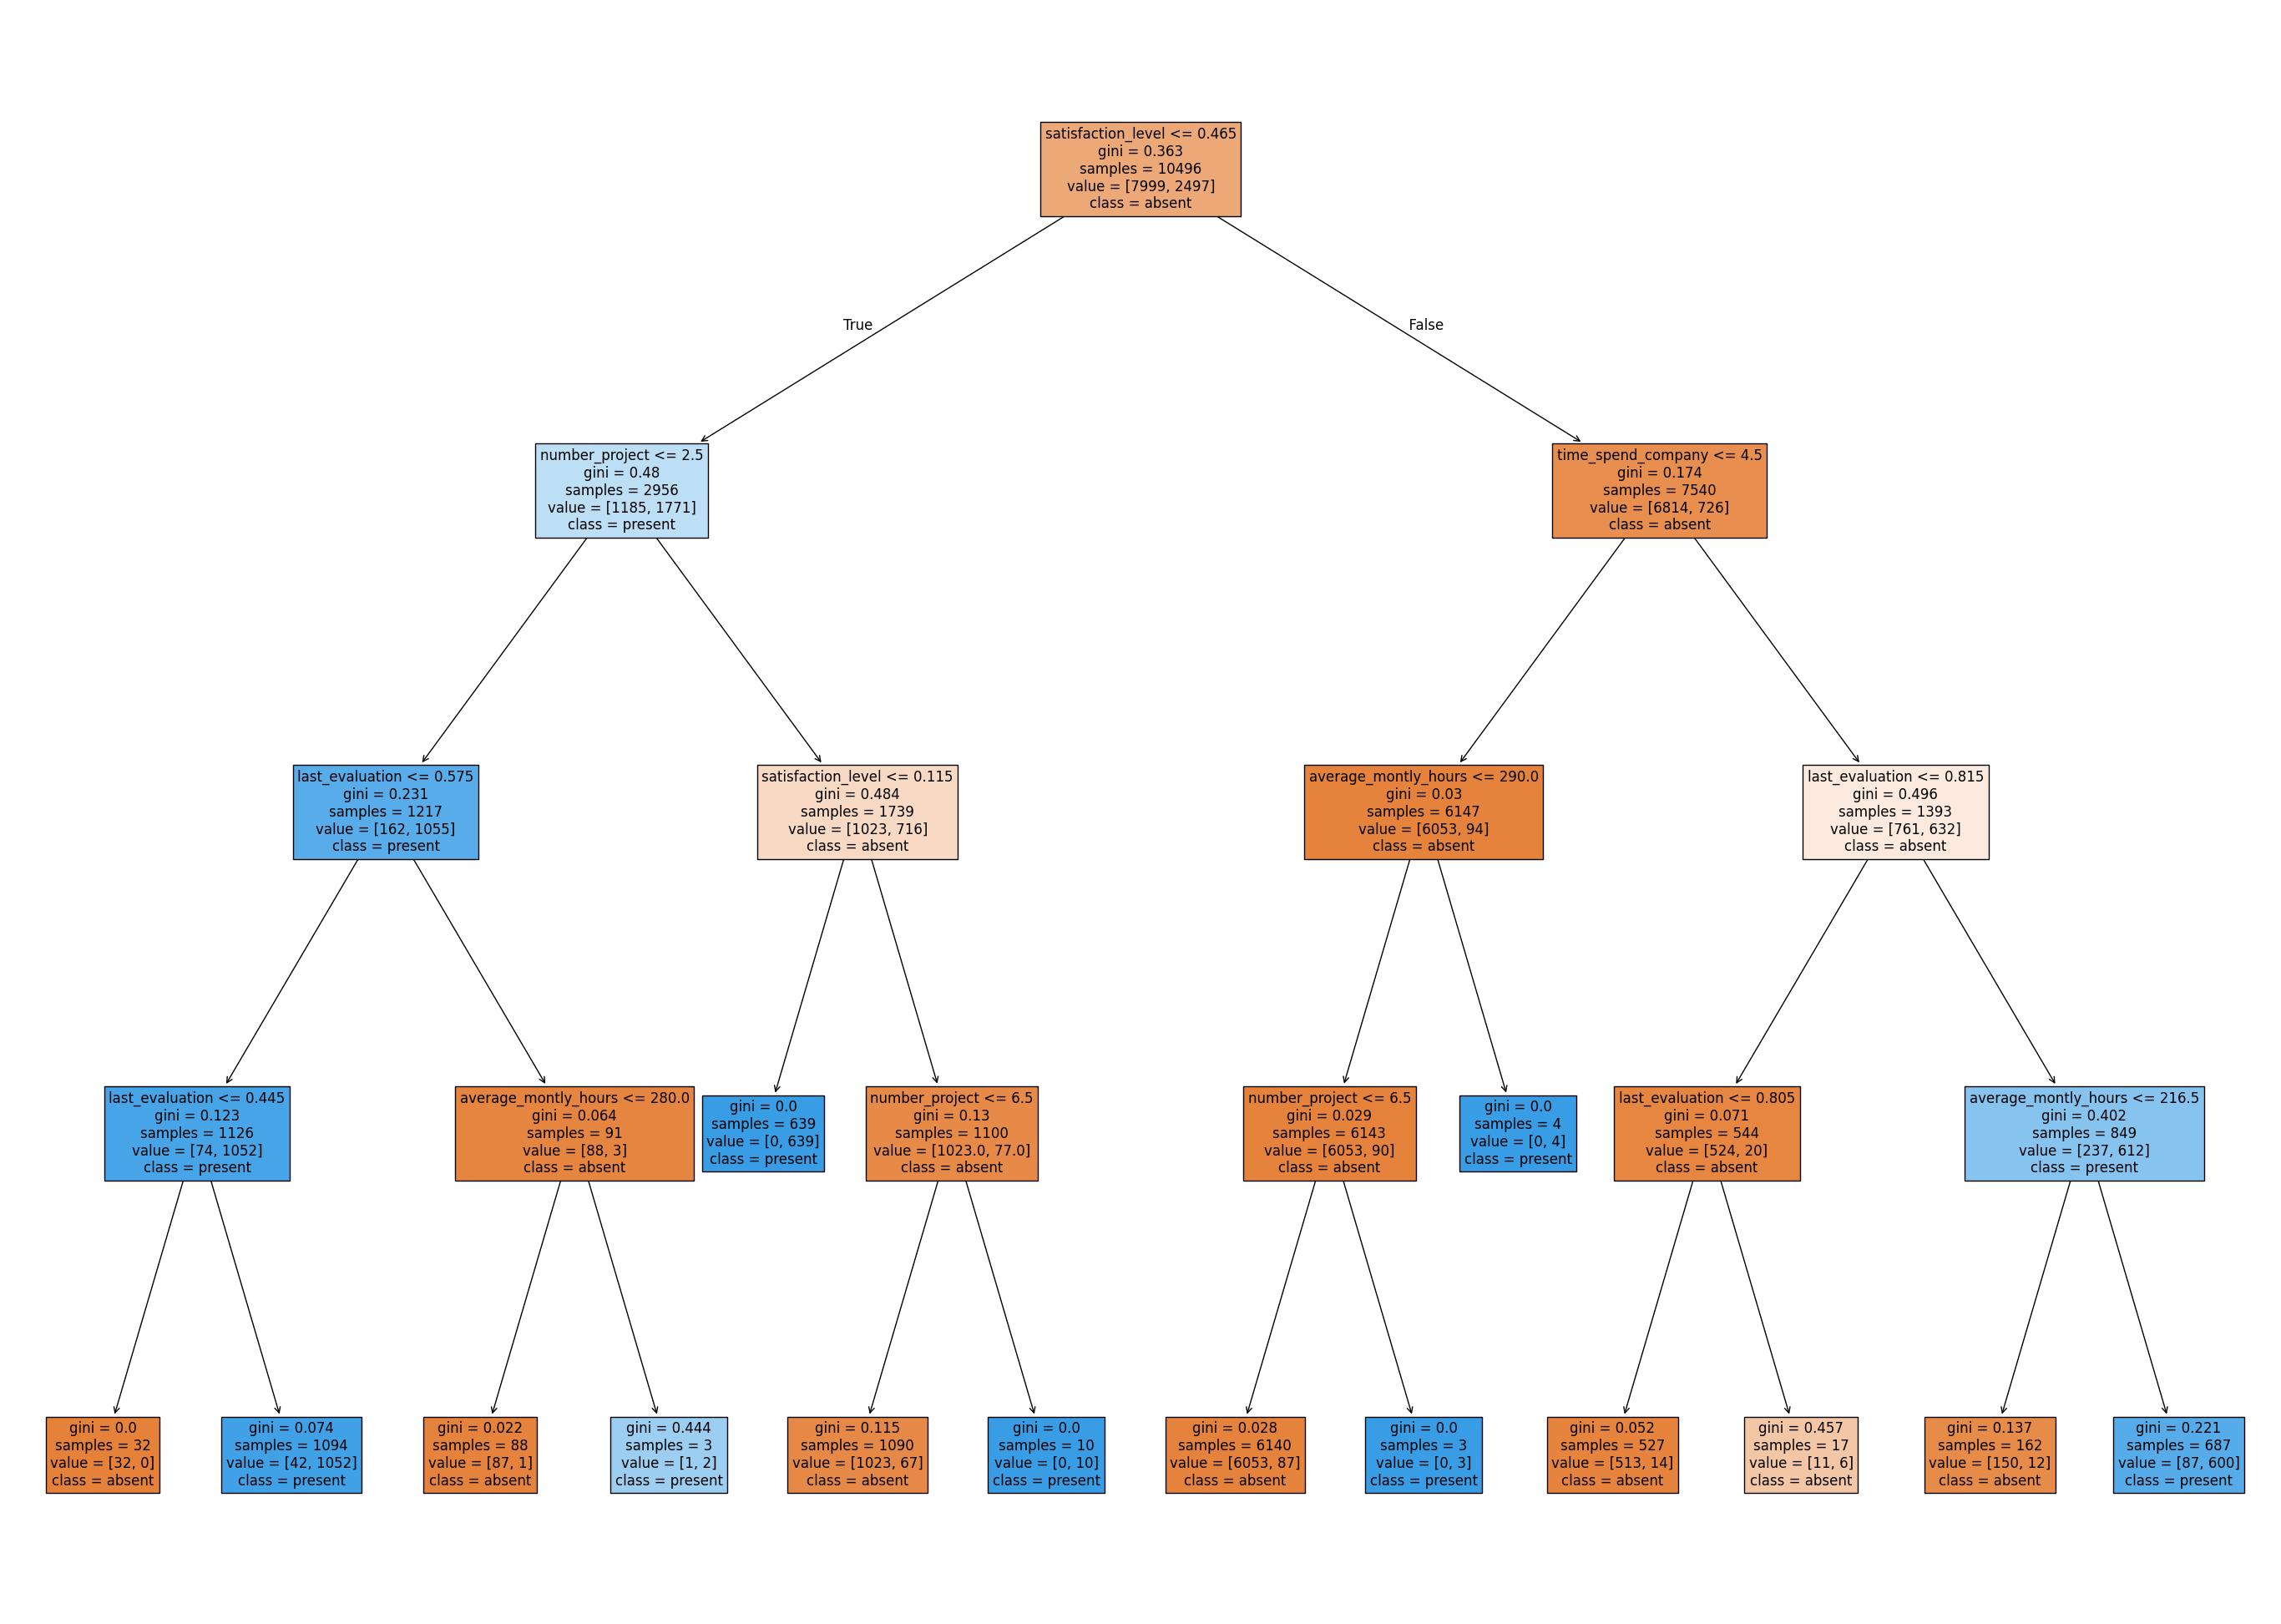

In [16]:
dtc = DecisionTreeClassifier(random_state=26,max_depth=4)
dtc.fit(X_trn_ohe, y_train)

plt.figure(figsize=(35, 25))
plot_tree(dtc, 
          feature_names=list(X_trn_ohe.columns), 
          class_names=['absent', 'present'], 
          filled=True, 
          fontsize=12)

plt.show()

In [25]:
depths=[1,2,3,5,None]
splits = [2,4,8,10,20,30,50,100]
leaves = [1,4,8,10,20,30,50,100]
scores=[]
for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc=DecisionTreeClassifier(random_state=26,max_depth=d,min_samples_split=s,min_samples_leaf=l)
            dtc.fit(X_trn_ohe,y_train)
            y_pred_prob=dtc.predict_proba(X_tst_ohe)
            y_pred=dtc.predict(X_tst_ohe)
            scores.append([d,s,l,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])


df_scores = pd.DataFrame(scores,columns=['depths','splits','leaves','accuracy_score','score'])
df_scores.sort_values('score')

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]

 20%|████████████████▊                                                                   | 1/5 [00:00<00:03,  1.12it/s]

 40%|█████████████████████████████████▌                                                  | 2/5 [00:02<00:03,  1.04s/it]

 60%|██████████████████████████████████████████████████▍                                 | 3/5 [00:03<00:02,  1.15s/it]

 80%|███████████████████████████████████████████████████████████████████▏                | 4/5 [00:04<00:01,  1.33s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.76s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.49s/it]

,depths,splits,leaves,accuracy_score,score
16,1.0,8,1,0.410563,0.826628
17,1.0,8,4,0.410563,0.826628
18,1.0,8,8,0.410563,0.826628
19,1.0,8,10,0.410563,0.826628
20,1.0,8,20,0.410563,0.826628
...,...,...,...,...,...
304,NaN,50,1,0.296306,0.976884
305,NaN,50,4,0.281184,0.977328
313,NaN,100,4,0.211284,0.977328
296,NaN,30,1,0.357835,0.977328


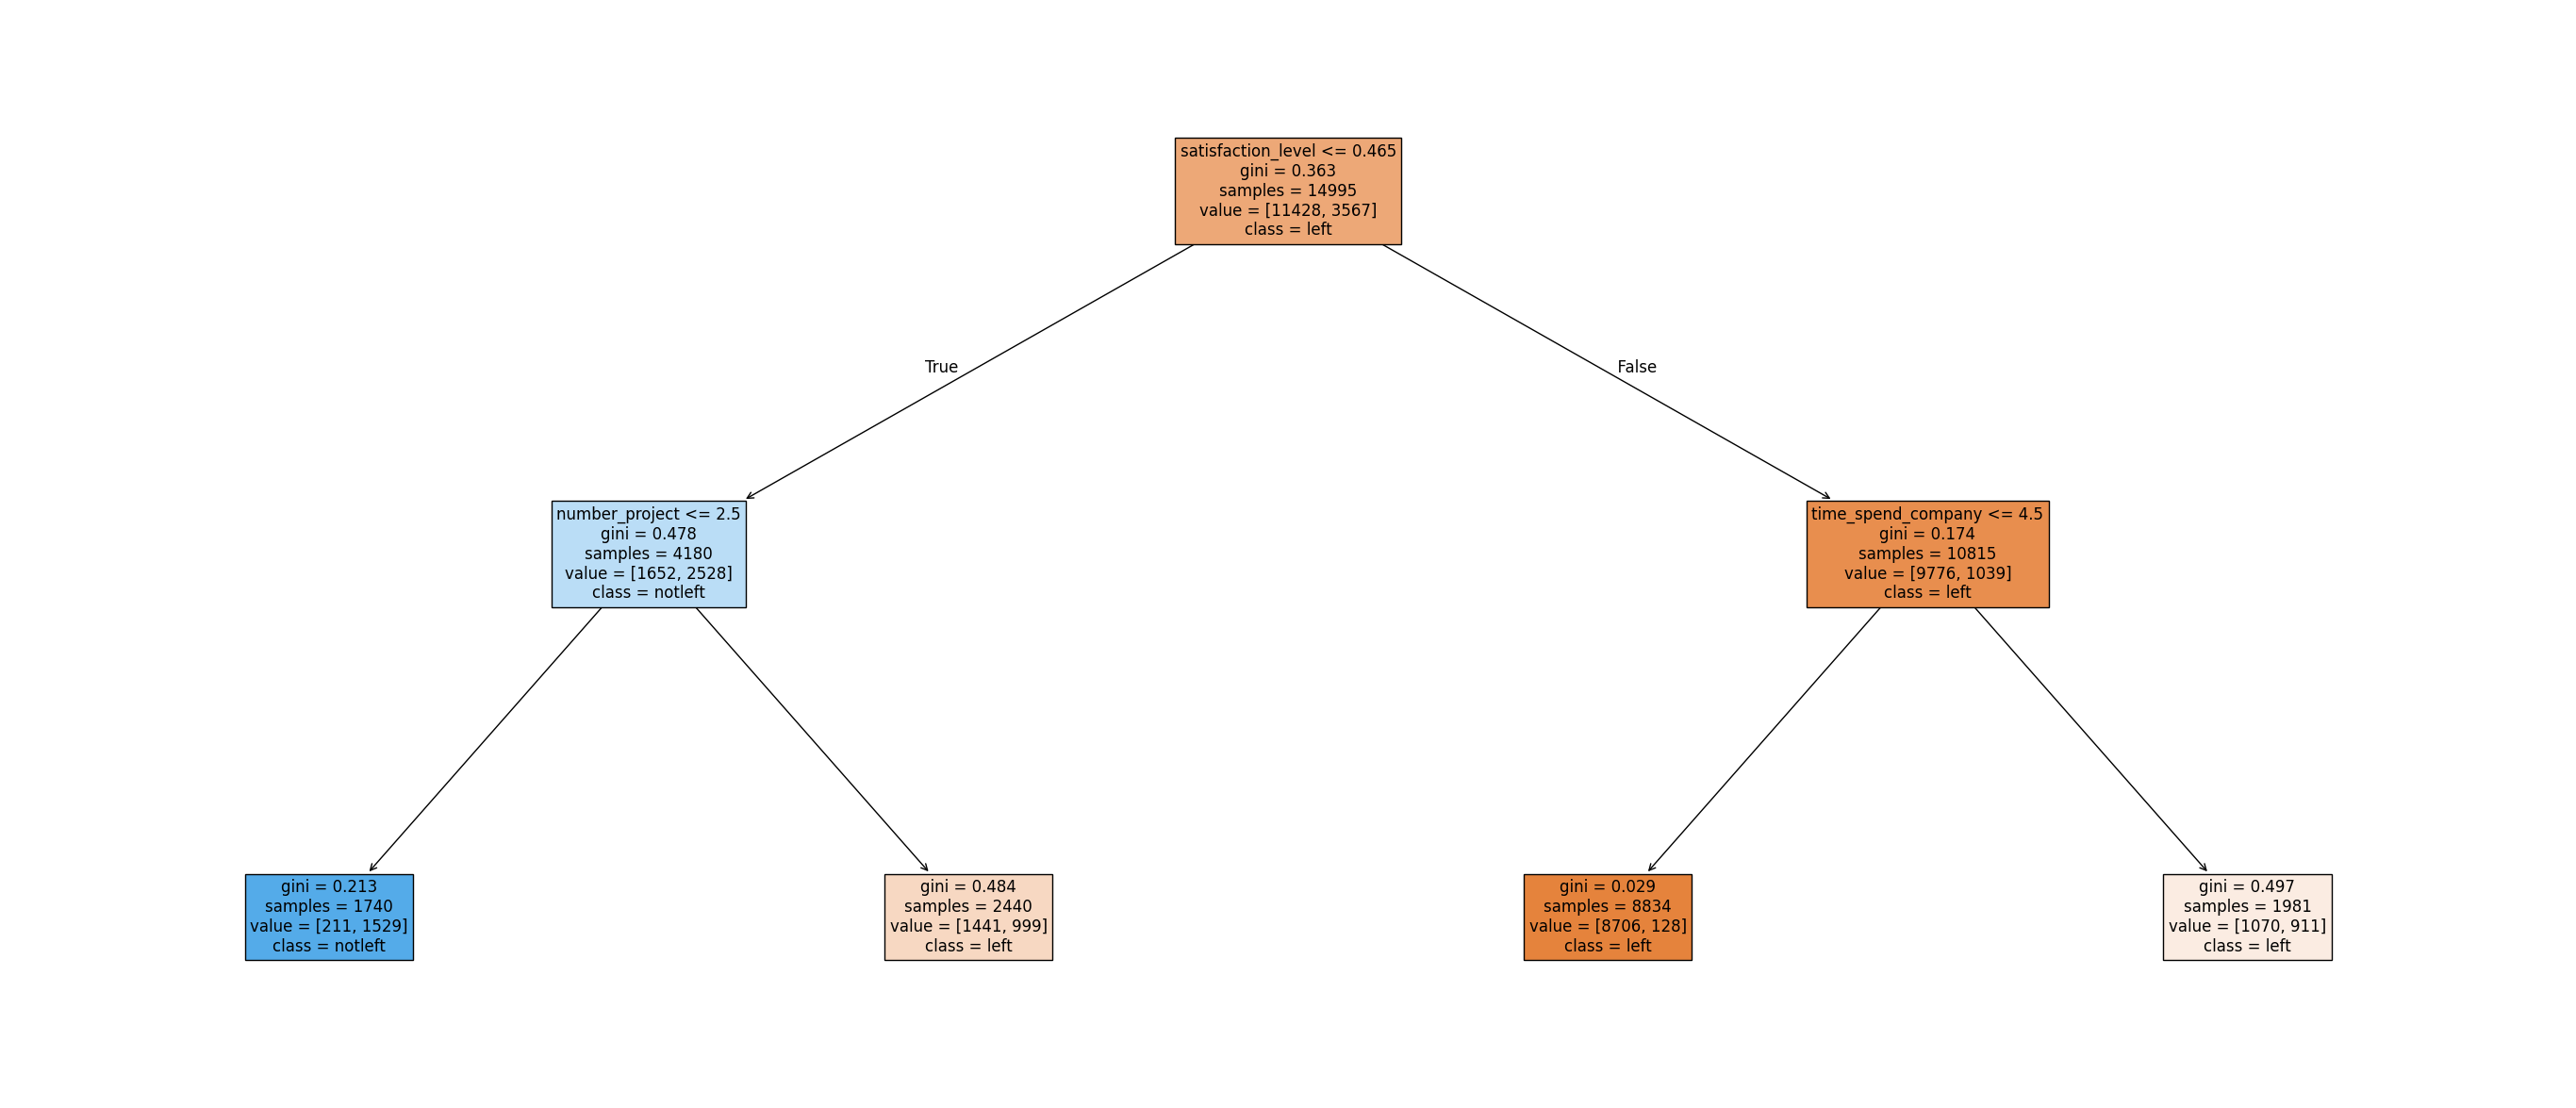

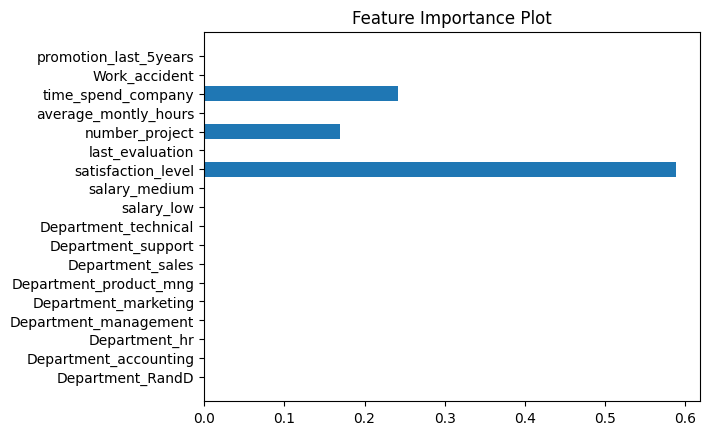

In [31]:

bm = DecisionTreeClassifier(  
                random_state=26,
                min_samples_leaf=30,
                min_samples_split=2,
                max_depth=2
            )
X_ohe = trans.fit_transform(X)

bm.fit(X_ohe,y)
plt.figure(figsize=(35, 15))

plot_tree(bm, feature_names = list(X_ohe.columns), class_names = ["left", "notleft"], filled = True, fontsize = 12)
plt.show()

df_imp = pd.DataFrame({'feature':X_ohe.columns,'importance':bm.feature_importances_})
plt.barh(df_imp['feature'],df_imp['importance'])
plt.title('Feature Importance Plot')
plt.show()